#### All imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

SavePlots = False

#### Import data

In [2]:
# NOTE: Change the path to get more data points (e.g. Nev10000, Nev50000, etc.)
data = pd.DataFrame(np.genfromtxt('AlephBtag_MC_train_Nev5000.csv', names=True))

variables = data.columns

# Decide what features we want to use for training the model.
# We exclude the label (isb) and the benchmark (nnbjet) + some irrelevant variables (energy, cTheta, phi).
feature_columns = variables[
    (variables != "nnbjet") &
    (variables != "isb") &
    (variables != "energy") &
    (variables != "cTheta") &
    (variables != "phi")
]

features = data[feature_columns] # X:           Total feature data (to be divided into training, validation & testing)
labels = data["isb"].astype(int) # Y_truth:     Binary labels (0 or 1) indicating whether the jet is a b-jet (isb=1) or not (isb=0)
aleph_nn_score = data["nnbjet"]  # Y_Benchmark: score from the ALEPH neural network (used for comparison with our model)

# REMOVE Backward-compatible aliases (used in later cells)
# input_variables = feature_columns
# input_data = features
# truth_data = labels
# benchmark_data = aleph_nn_score

#### Plot data

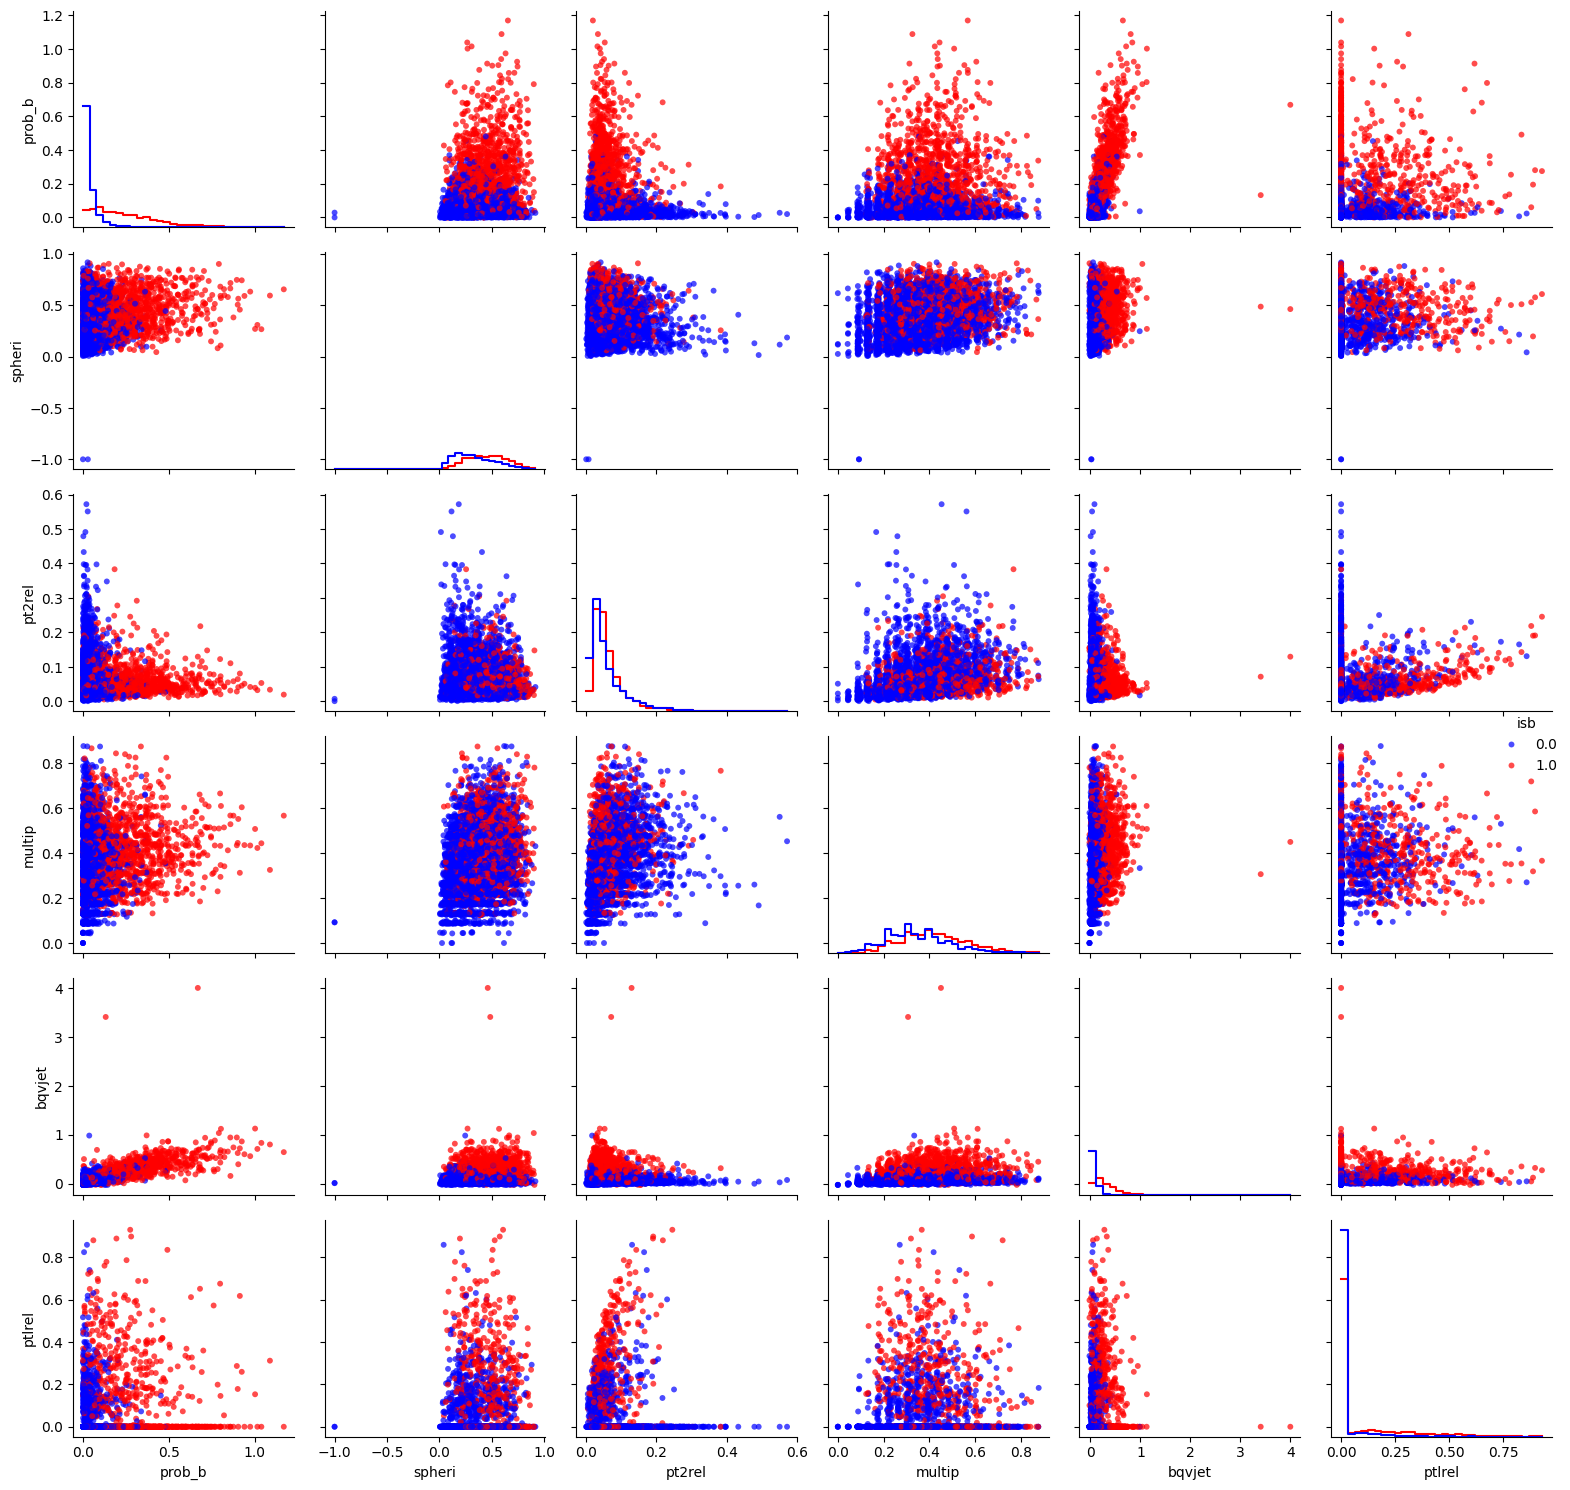

In [3]:
df = pd.DataFrame(data)  # Create copy of data for viz purpose
df = df.drop(['energy', 'cTheta', 'phi', 'nnbjet'], axis=1)

g = sns.pairplot(
    df,
    hue="isb",
    diag_kind="hist",
    palette={0: "blue", 1: "red"},
    plot_kws={
        "s": 18,
        "alpha": 0.7,
        "edgecolor": "none",
        "linewidth": 0
    },
    diag_kws={
        "stat": "density",
        "common_norm": False,
        "bins": 30,
        "element": "step",
        "fill": False,
        "linewidth": 1.5
    }
)

g.figure.tight_layout()
plt.show()


#### Correlation matrices

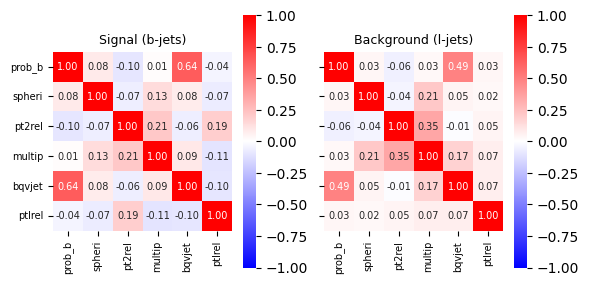

In [4]:
# Separate data by label
df_b = df[df['isb'] == 1].drop(columns=['isb']) # Signal (b-jets)
df_l = df[df['isb'] == 0].drop(columns=['isb']) # Background (l-jets)


# Calculate correlation matrices by label
corr_b = df_b.corr(method='pearson')
corr_l = df_l.corr(method='pearson')

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

sns.heatmap(
    corr_b, ax=axes[0], cmap="bwr", vmin=-1, vmax=1,
    annot=True, fmt=".2f", square=True, cbar=True,
    annot_kws={"size": 7}
)
axes[0].set_title("Signal (b-jets)", fontsize=9)
axes[0].tick_params(axis="both", labelsize=7)

sns.heatmap(
    corr_l, ax=axes[1], cmap="bwr", vmin=-1, vmax=1,
    annot=True, fmt=".2f", square=True, cbar=True,
    annot_kws={"size": 7}
)
axes[1].set_title("Background (l-jets)", fontsize=9)
axes[1].tick_params(axis="both", labelsize=7)

plt.tight_layout()
plt.show()


In  `BjetSelection_ExampleSolution.ipynb`, Troels comments on what we can conclude from these matrices.

#### Parsing data
Shared data split over all models, for fair comparison

In [5]:
def split_threeway(X, y, train_pct, val_pct, test_pct, random_state=42, stratify=True):
    if not np.isclose(train_pct + val_pct + test_pct, 1.0):
        raise ValueError("train_pct + val_pct + test_pct must add to 1.")

    # First split: test vs (train+val)
    strat1 = y if stratify else None
    X_temp, X_test, y_temp, y_test = train_test_split(
        X,
        y,
        test_size=test_pct,
        random_state=random_state,
        stratify=strat1
    )

    # Second split: val vs train within remaining data
    val_relative = val_pct / (train_pct + val_pct)
    strat2 = y_temp if stratify else None
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=val_relative,
        random_state=random_state,
        stratify=strat2
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test = split_threeway(
    features, labels, train_pct=0.7, val_pct=0.15, test_pct=0.15, random_state=42, stratify=True
)

#### Decision tree w. `XGBoost`
First, we train a decision tree *binary classifier* (in that it distinguishes between two classes; l-jets and b-jets), using `XGBoost`.
We train the model on the input data, `X_train`, to predict whether points within the test data, `X_test` is true/false with respect to the label `isb` (is it a b-jet?). 


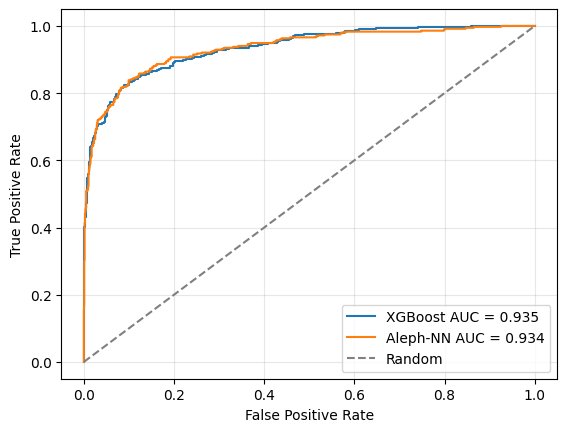

In [ ]:
# Setup
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.06,  # Does this do stochastic gradient descent behind the scenes?
    max_depth=2,        # Max depth - more shallow trees better than few deep
    eval_metric='logloss', # Loss function to optimize
    n_estimators=1000, # Equivalent to number of parallel trees
    seed=42 # ?? random a
)
xgb_clf.fit(X_train, y_train)

# Get scores for ROC
y_score = xgb_clf.predict_proba(X_test)[:, 1]

# IMPORTANT: align benchmark to test-set indices
y_benchmark_test = benchmark_data.loc[X_test.index]

# ROC for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_score)
auc_xgb = roc_auc_score(y_test, y_score)

# ROC for benchmark (Aleph-NN)
fpr_bm, tpr_bm, _ = roc_curve(y_test, y_benchmark_test)
auc_bm = roc_auc_score(y_test, y_benchmark_test)

# Plot both
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost AUC = {auc_xgb:.3f}')
plt.plot(fpr_bm, tpr_bm, label=f'Aleph-NN AUC = {auc_bm:.3f}')
plt.plot([0, 1], [0, 1], ls='--', c="gray", label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

AUC stands for Area Under the ROC Curve.

Here it is a single-number summary of classifier quality:
* 1.0 = perfect separation
* 0.5 = random guessing
* < 0.5 = worse than random (often means score direction is flipped)


So in your plot, higher AUC means better overall discrimination between b-jets and l-jets across all

#### Feature importance
Feature importance tells how much each input variable contributed to the XGBoost model’s splits.

For XGBoost, the simplest version is based on how often a feature is used and how much it improves the splits. Higher value = more important.

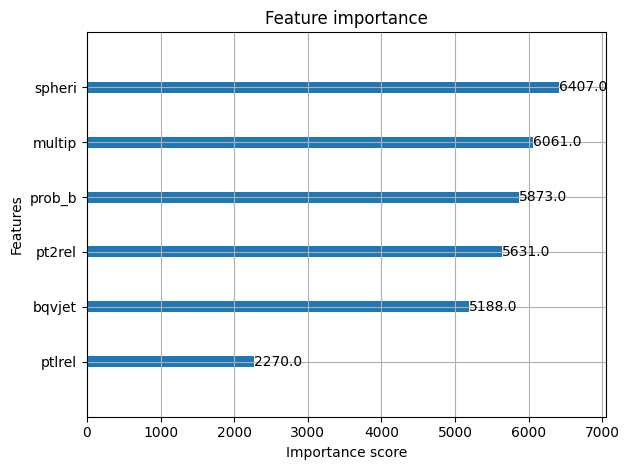

In [20]:
xgb.plot_importance(xgb_clf, importance_type="weight")
plt.tight_layout()
plt.show()


#### Decision tree w. `LightGBM`

In [ ]:
# Insert some code

#### Neural network w. `Scikit-learn`

In [35]:
# scikit-learn neural network
mlp_clf = make_pipeline(              # Setup the "shape" of the model (neural network, how optimization is done, etc.)
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(64, 64),  # Two hidden layers with 64 neurons each
        activation="relu",            # Chosen shape for the activation function
        solver="adam",                # Adaptive Moment Estimation (adam); a optimized version of stochastic gradient descent (SGD) used for training
        alpha=1e-4,                   # Not sure what this is
        learning_rate_init=1e-3,      # Learning rate (eta) - initial step size for gradient descent (is later adapted)
        max_iter=2000,                # Maximum number of iterations (epochs) for training
        random_state=42               # Random seed
    )
)

mlp_clf.fit(X_train, y_train) # Feeding the data and labels to the model for training (adjusting the model weights to minimize the loss function)

# Evaluate the performance of the trained model on both the training and test sets using accuracy as the metric.
y_pred_train = mlp_clf.predict(X_train)
y_pred_test = mlp_clf.predict(X_test)
print(f"MLP train accuracy: {accuracy_score(y_train, y_pred_train)*100:.2f}%")
print(f"MLP test  accuracy: {accuracy_score(y_test, y_pred_test)*100:.2f}%")

# visualize boundary on full sample
plot_boundary_results(X.values, y.values, mlp_clf)
# ...existing code...

MLP train accuracy: 92.94%
MLP test  accuracy: 90.00%


NameError: name 'plot_boundary_results' is not defined

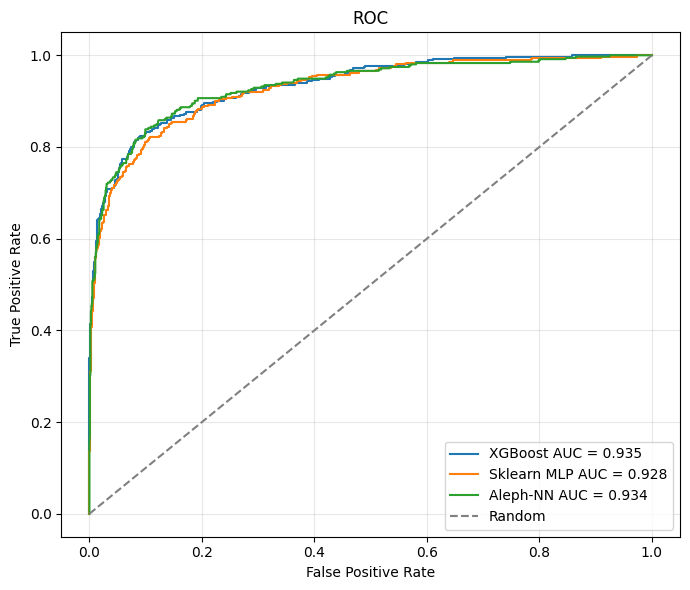

In [60]:
# --- XGBoost ---
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    learning_rate=0.06,
    max_depth=2,
    eval_metric="logloss",
    n_estimators=1000,
    seed=42
)
xgb_clf.fit(X_train, y_train)
y_score_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# --- scikit-learn Neural Network (MLP) ---
mlp_clf = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=2000,
        random_state=42
    )
)
mlp_clf.fit(X_train, y_train)
y_score_mlp = mlp_clf.predict_proba(X_test)[:, 1]

# --- Aleph-NN benchmark ---
y_score_aleph = benchmark_data.loc[X_test.index].values

# ROC + AUC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_score_xgb)
auc_xgb = roc_auc_score(y_test, y_score_xgb)

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_score_mlp)
auc_mlp = roc_auc_score(y_test, y_score_mlp)

fpr_aleph, tpr_aleph, _ = roc_curve(y_test, y_score_aleph)
auc_aleph = roc_auc_score(y_test, y_score_aleph)

# Plot comparison
plt.figure(figsize=(7, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {auc_xgb:.3f}")
plt.plot(fpr_mlp, tpr_mlp, label=f"Sklearn MLP AUC = {auc_mlp:.3f}")
plt.plot(fpr_aleph, tpr_aleph, label=f"Aleph-NN AUC = {auc_aleph:.3f}")
plt.plot([0, 1], [0, 1], ls="--", c="gray", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# ...existing code...

## Questions:

1. ✅ Start by plotting the six "Aleph classification variables" and calculate their correlation matrices for signal and background, and see which seems to separate and correlate most (optional).

2. ✅ Above, the scoring is simply done by considering the fraction of wrong estimates. Think about what the alternatives could be, especially if you were to give a continuous score like the Aleph-NN. This scoring is called the "loss function".

3. ✅Draw ROC curves for each of these six separately, to quantify the separation. Also draw the Aleph-NN variable (nnbjet). Is the Aleph-NN better? Are any of the variables "seemingly worthless"? (we will return to this point later).

Note that decision variables (i.e. 0 and 1) yield a single point in the ROC curve plot.

5. <b>Try to get a BDT to make predictions based on the six given input variables. Plot the result in the ROC curve, and see if you managed to compete or even improve upon the Aleph-NN scores.</b>

6. <b>Think about what data you based your predictions on? Was it the same data that you trained the algorithm on? And if that is the case, is that reasonable?<b>

7. Does including more data (50000 instead of 5000 events) improve your performance?

8. Does including the kinematic variables 'energy', 'cTheta', and 'phi' (which are not related to jet type) improve your performance?

## Learning points:

From this exercise you should:

1. get a feel for the problem at hand, namely to separate two populations in a 6-dimensional space. It is hard to imagine, yet with simple cuts you should be able to get "some performance", though never close to the Aleph-NN.

2. learn, that it is hard to do "by hand", but that at least the fact that you have known cases (i.e. labels) makes you capable of getting some performance.

3. be able to draw ROC curves to compare performances between different variables and scores (floating or discrete).

4. know that you can (typically) improve the performance through the use of Machine Learning (ML).

5. <b>be capable not only of getting ML results, but also confident in optimising them, and certainly proficient in interpreting them.</b>